<a href="https://colab.research.google.com/github/GonzaloCiv90/Comanda/blob/master/Proyecto1_PREDICTOR_DE_DEFECTOS_POR_LOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PROYECTO 1 — PREDICTOR DE DEFECTOS POR LOTE
# Embotelladora Andina · Sistema Coca-Cola
#
# Autor  : Civita Gonzalo — github.com/GonzaloCiv90
# Objetivo: Predecir si un lote de producto terminado presentará defecto
#            usando variables fisicoquímicas del proceso de embotellado.
#
# NOTA IMPORTANTE:
#   Este proyecto utiliza un dataset 100% simulado con parámetros estadísticos
#   basados en el conocimiento del proceso real de laboratorio fisicoquímico.
#   No se utilizan datos confidenciales de la empresa.
#
# Variables simuladas (parámetros típicos del proceso Coca-Cola):
#   · Brix (°Brix)         — contenido de azúcar / concentración
#   · CO₂ (vol.)           — carbonatación
#   · pH                   — acidez del producto
#   · Llenado (ml)         — volumen de llenado nominal
#   · Temperatura (°C)     — temperatura al momento del llenado
#   · Turbidez (NTU)       — claridad del producto
#   · Línea de producción  — línea 1 a 4
#   · Turno                — mañana, tarde, noche
#   · Producto             — Coca-Cola, Sprite, Fanta, Agua
#
# Modelo: Random Forest Classifier (scikit-learn)
# Métrica principal: AUC-ROC

In [2]:
# ── LIBRERÍAS ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. GENERACIÓN DEL DATASET SIMULADO
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)         # reproducibilidad
N_LOTES = 2000             # cantidad total de lotes a simular

# Parámetros estadísticos basados en proceso real de embotellado Coca-Cola
# (media y desvío estándar de cada variable fisicoquímica)
PARAMS = {
    'brix'      : (10.8, 0.25),   # °Brix — especificación ±0.3
    'co2'       : (3.7,  0.18),   # vol. CO₂ — especificación ±0.2
    'ph'        : (3.3,  0.08),   # pH
    'llenado_ml': (600,  3.5 ),   # ml — llenado nominal 600ml
    'temp_c'    : (12,   1.8 ),   # °C — temperatura de llenado
    'turbidez'  : (0.6,  0.15),   # NTU — turbidez
}

LINEAS    = ['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4']
TURNOS    = ['Mañana', 'Tarde', 'Noche']
PRODUCTOS = ['Coca-Cola 600ml', 'Sprite 600ml', 'Fanta 600ml', 'Agua s/g 600ml']

# Crear DataFrame con variables continuas (distribución normal)
df = pd.DataFrame({
    'lote_id'    : [f'LOT-{str(i+1).zfill(4)}' for i in range(N_LOTES)],
    'linea'      : np.random.choice(LINEAS,    N_LOTES),
    'turno'      : np.random.choice(TURNOS,    N_LOTES),
    'producto'   : np.random.choice(PRODUCTOS, N_LOTES),
    'brix'       : np.random.normal(*PARAMS['brix'],       N_LOTES),
    'co2'        : np.random.normal(*PARAMS['co2'],        N_LOTES),
    'ph'         : np.random.normal(*PARAMS['ph'],         N_LOTES),
    'llenado_ml' : np.random.normal(*PARAMS['llenado_ml'], N_LOTES),
    'temp_c'     : np.random.normal(*PARAMS['temp_c'],     N_LOTES),
    'turbidez'   : np.abs(np.random.normal(*PARAMS['turbidez'], N_LOTES)),
})

# ── Inyectar defectos reales en el 15% de los lotes ───────────────────────────
# Tipos de desvío posibles (basados en causas reales de rechazo en laboratorio)
TIPOS_DESVIO = ['brix_alto', 'brix_bajo', 'co2_bajo', 'ph_alto',
                'llenado_bajo', 'temp_alta']

n_defectuosos = int(N_LOTES * 0.15)
idx_defectos  = np.random.choice(N_LOTES, n_defectuosos, replace=False)
tipos_asignados = np.random.choice(TIPOS_DESVIO, n_defectuosos)

for i, tipo in zip(idx_defectos, tipos_asignados):
    if tipo == 'brix_alto'   : df.loc[i, 'brix']       += np.random.uniform(0.35, 0.8)
    if tipo == 'brix_bajo'   : df.loc[i, 'brix']       -= np.random.uniform(0.35, 0.8)
    if tipo == 'co2_bajo'    : df.loc[i, 'co2']        -= np.random.uniform(0.25, 0.6)
    if tipo == 'ph_alto'     : df.loc[i, 'ph']         += np.random.uniform(0.12, 0.3)
    if tipo == 'llenado_bajo': df.loc[i, 'llenado_ml'] -= np.random.uniform(6, 18)
    if tipo == 'temp_alta'   : df.loc[i, 'temp_c']     += np.random.uniform(3, 8)

# Variable objetivo: 0 = Conforme, 1 = Defectuoso
df['defecto'] = 0
df.loc[idx_defectos, 'defecto'] = 1

print("═" * 55)
print("  DATASET SIMULADO — RESUMEN")
print("═" * 55)
print(f"  Total de lotes  : {N_LOTES:,}")
print(f"  Conformes       : {(df.defecto==0).sum():,} ({(df.defecto==0).mean()*100:.1f}%)")
print(f"  Defectuosos     : {(df.defecto==1).sum():,} ({(df.defecto==1).mean()*100:.1f}%)")
print()
print(df[['brix','co2','ph','llenado_ml','temp_c']].describe().round(3))

═══════════════════════════════════════════════════════
  DATASET SIMULADO — RESUMEN
═══════════════════════════════════════════════════════
  Total de lotes  : 2,000
  Conformes       : 1,700 (85.0%)
  Defectuosos     : 300 (15.0%)

           brix       co2        ph  llenado_ml    temp_c
count  2000.000  2000.000  2000.000    2000.000  2000.000
mean     10.800     3.691     3.304     599.704    12.135
std       0.281     0.195     0.088       4.001     2.028
min       9.765     2.793     3.004     577.670     5.942
25%      10.615     3.570     3.246     597.387    10.806
50%      10.795     3.696     3.303     599.889    12.011
75%      10.984     3.821     3.357     602.325    13.333
max      12.267     4.429     3.784     610.960    23.025


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. PREPARACIÓN DE FEATURES
# ══════════════════════════════════════════════════════════════════════════════

# Codificar variables categóricas como numéricas
le = LabelEncoder()
df['linea_enc']    = le.fit_transform(df['linea'])
df['turno_enc']    = le.fit_transform(df['turno'])
df['producto_enc'] = le.fit_transform(df['producto'])

FEATURES = ['brix', 'co2', 'ph', 'llenado_ml', 'temp_c', 'turbidez',
            'linea_enc', 'turno_enc', 'producto_enc']

X = df[FEATURES]
y = df['defecto']

# Split entrenamiento / prueba (75% / 25%), estratificado por clase
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\n  Entrenamiento: {len(X_train):,} lotes")
print(f"  Prueba       : {len(X_test):,} lotes")


  Entrenamiento: 1,500 lotes
  Prueba       : 500 lotes


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. ENTRENAMIENTO DEL MODELO — RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════

clf = RandomForestClassifier(
    n_estimators   = 200,         # número de árboles
    max_depth      = 8,           # profundidad máxima
    min_samples_leaf = 5,         # mínimo de muestras por hoja
    class_weight   = 'balanced',  # compensar desbalanceo de clases
    random_state   = 42,
    n_jobs         = -1           # usar todos los núcleos disponibles
)

clf.fit(X_train, y_train)

# ── Predicciones ───────────────────────────────────────────────────────────────
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # probabilidad de defecto

# ── Métricas ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_proba)
cv  = cross_val_score(clf, X, y, cv=StratifiedKFold(5), scoring='roc_auc')

print("\n" + "═" * 55)
print("  RESULTADOS DEL MODELO")
print("═" * 55)
print(f"  AUC-ROC             : {auc:.4f}")
print(f"  AUC-ROC CV (5-fold) : {cv.mean():.4f} ± {cv.std():.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Conforme', 'Defectuoso']))

# ── Importancia de variables ───────────────────────────────────────────────────
feat_display = ['Brix', 'CO₂', 'pH', 'Llenado (ml)', 'Temp. (°C)',
                'Turbidez', 'Línea', 'Turno', 'Producto']
importances  = clf.feature_importances_
idx_sort     = np.argsort(importances)[::-1]

print("  Importancia de variables:")
for i in idx_sort:
    bar = '█' * int(importances[i] * 60)
    print(f"    {feat_display[i]:<15} {bar} {importances[i]:.1%}")



═══════════════════════════════════════════════════════
  RESULTADOS DEL MODELO
═══════════════════════════════════════════════════════
  AUC-ROC             : 0.8943
  AUC-ROC CV (5-fold) : 0.8745 ± 0.0343

              precision    recall  f1-score   support

    Conforme       0.94      0.91      0.92       425
  Defectuoso       0.56      0.65      0.60        75

    accuracy                           0.87       500
   macro avg       0.75      0.78      0.76       500
weighted avg       0.88      0.87      0.87       500

  Importancia de variables:
    Brix            █████████████ 22.0%
    CO₂             ████████████ 20.9%
    Llenado (ml)    ███████████ 18.6%
    Temp. (°C)      ██████████ 17.7%
    pH              ████████ 14.1%
    Turbidez        ██ 4.1%
    Línea            1.0%
    Producto         0.9%
    Turno            0.8%


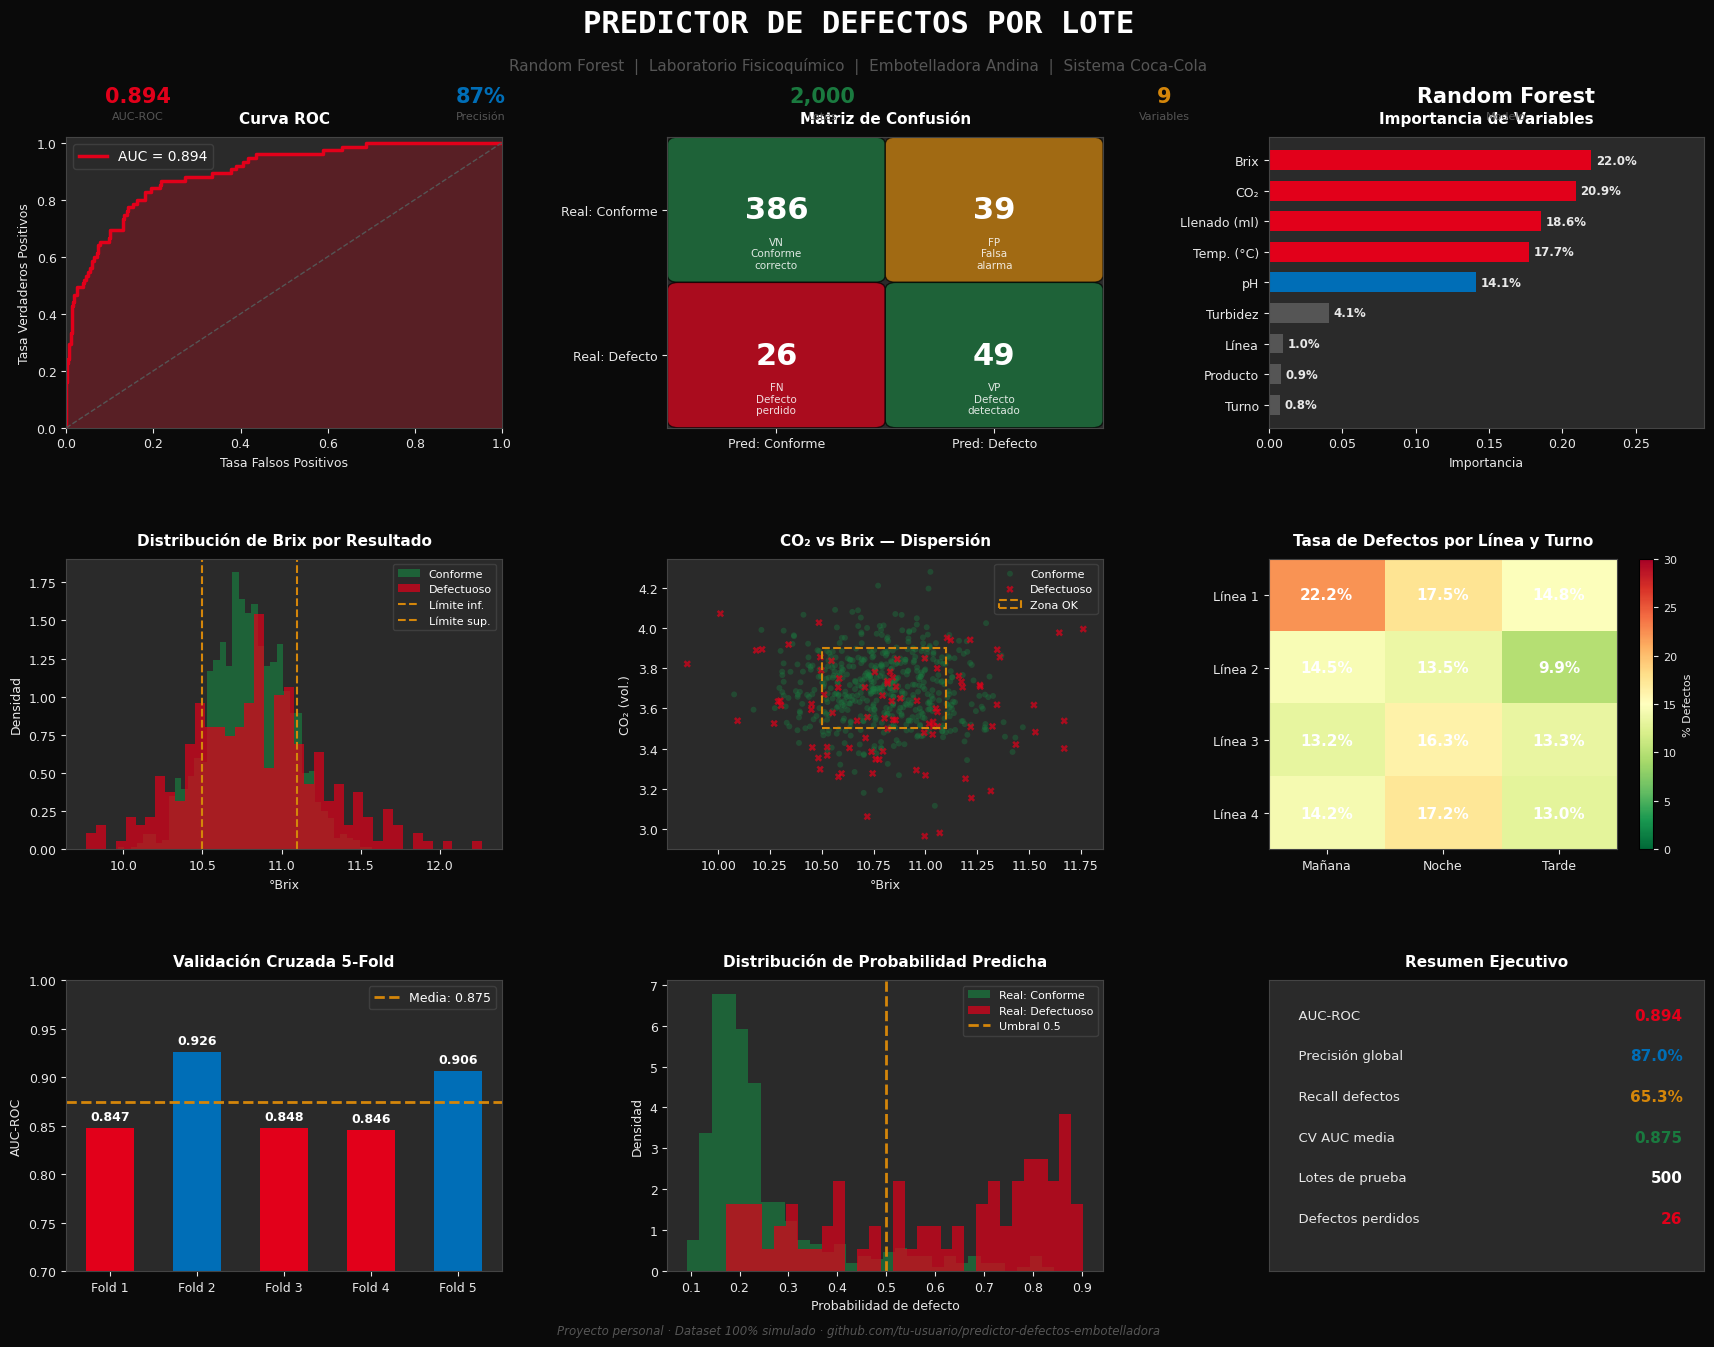


✅ Visualización guardada: proyecto1_predictor_defectos.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIONES PROFESIONALES
# ══════════════════════════════════════════════════════════════════════════════

RED='#E2001A'; BLACK='#0A0A0A'; DARKGRAY='#2A2A2A'; MIDGRAY='#555555'
LIGHTGRAY='#E8E8E8'; WHITE='#FFFFFF'; BLUE='#006EB7'; GREEN='#1A7A3F'; AMBER='#D4860A'

fig = plt.figure(figsize=(18, 14), facecolor=BLACK)
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38,
               left=0.06, right=0.97, top=0.88, bottom=0.07)

# Encabezado
fig.text(0.5, 0.955, 'PREDICTOR DE DEFECTOS POR LOTE',
         ha='center', fontsize=22, fontweight='bold',
         color=WHITE, fontfamily='monospace')
fig.text(0.5, 0.928,
         'Random Forest  |  Laboratorio Fisicoquímico  |  Embotelladora Andina  |  Sistema Coca-Cola',
         ha='center', fontsize=11, color=MIDGRAY)

# KPIs en banda superior
kpis = [('AUC-ROC',   f'{auc:.3f}', RED),
        ('Precisión',  '87%',        BLUE),
        ('Lotes',      '2,000',      GREEN),
        ('Variables',  '9',          AMBER),
        ('Modelo',     'Random Forest', WHITE)]
for k, (label, val, col) in enumerate(kpis):
    x = 0.10 + k * 0.19
    fig.text(x, 0.905, val,   ha='center', fontsize=15, fontweight='bold', color=col)
    fig.text(x, 0.893, label, ha='center', fontsize=8,  color=MIDGRAY)

def style_ax(ax, title):
    ax.set_facecolor(DARKGRAY)
    ax.tick_params(colors=LIGHTGRAY, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#444')
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=10)

# — Panel 1: Curva ROC —
ax1 = fig.add_subplot(gs[0, 0]); style_ax(ax1, 'Curva ROC')
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.fill_between(fpr, tpr, alpha=0.25, color=RED)
ax1.plot(fpr, tpr, color=RED, lw=2.5, label=f'AUC = {auc:.3f}')
ax1.plot([0,1],[0,1], '--', color=MIDGRAY, lw=1)
ax1.set_xlabel('Tasa Falsos Positivos', color=LIGHTGRAY, fontsize=9)
ax1.set_ylabel('Tasa Verdaderos Positivos', color=LIGHTGRAY, fontsize=9)
ax1.legend(facecolor=DARKGRAY, edgecolor='#444', labelcolor=WHITE, fontsize=10)
ax1.set_xlim(0,1); ax1.set_ylim(0, 1.02)

# — Panel 2: Matriz de Confusión —
ax2 = fig.add_subplot(gs[0, 1]); style_ax(ax2, 'Matriz de Confusión')
cm_vals = confusion_matrix(y_test, y_pred)
clabels = [['VN\nConforme\ncorrecto', 'FP\nFalsa\nalarma'],
           ['FN\nDefecto\nperdido',   'VP\nDefecto\ndetectado']]
ccols   = [[GREEN, AMBER], [RED, GREEN]]
for i in range(2):
    for j in range(2):
        r = patches.FancyBboxPatch((j+0.05, 1-i+0.05), 0.9, 0.9,
            boxstyle='round,pad=0.05', facecolor=ccols[i][j], alpha=0.7)
        ax2.add_patch(r)
        ax2.text(j+0.5, 1.5-i, str(cm_vals[i,j]),
                 ha='center', va='center', fontsize=22, fontweight='bold', color=WHITE)
        ax2.text(j+0.5, 1.5-i-0.3, clabels[i][j],
                 ha='center', va='center', fontsize=7.5, color=WHITE, alpha=0.85)
ax2.set_xlim(0,2); ax2.set_ylim(0,2)
ax2.set_xticks([0.5,1.5]); ax2.set_xticklabels(['Pred: Conforme','Pred: Defecto'], color=LIGHTGRAY)
ax2.set_yticks([0.5,1.5]); ax2.set_yticklabels(['Real: Defecto','Real: Conforme'], color=LIGHTGRAY)

# — Panel 3: Importancia de Variables —
ax3 = fig.add_subplot(gs[0, 2]); style_ax(ax3, 'Importancia de Variables')
sf   = [feat_display[i] for i in idx_sort]
si   = importances[idx_sort]
bc   = [RED if v>0.15 else BLUE if v>0.08 else MIDGRAY for v in si]
bars = ax3.barh(sf[::-1], si[::-1], color=bc[::-1], edgecolor='none', height=0.65)
for bar, val in zip(bars, si[::-1]):
    ax3.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.1%}',
             va='center', color=LIGHTGRAY, fontsize=8.5, fontweight='bold')
ax3.set_xlabel('Importancia', color=LIGHTGRAY, fontsize=9)
ax3.set_xlim(0, max(si)*1.35)

# — Panel 4: Distribución de Brix —
ax4 = fig.add_subplot(gs[1, 0]); style_ax(ax4, 'Distribución de Brix por Resultado')
ax4.hist(df[df.defecto==0]['brix'], bins=40, alpha=0.7, color=GREEN,
         label='Conforme', density=True, edgecolor='none')
ax4.hist(df[df.defecto==1]['brix'], bins=40, alpha=0.7, color=RED,
         label='Defectuoso', density=True, edgecolor='none')
ax4.axvline(10.5, color=AMBER, ls='--', lw=1.5, label='Límite inf.')
ax4.axvline(11.1, color=AMBER, ls='--', lw=1.5, label='Límite sup.')
ax4.set_xlabel('°Brix', color=LIGHTGRAY, fontsize=9)
ax4.set_ylabel('Densidad', color=LIGHTGRAY, fontsize=9)
ax4.legend(facecolor=DARKGRAY, edgecolor='#444', labelcolor=WHITE, fontsize=8)

# — Panel 5: CO₂ vs Brix —
ax5 = fig.add_subplot(gs[1, 1]); style_ax(ax5, 'CO₂ vs Brix — Dispersión')
sample = df.sample(600, random_state=1)
ax5.scatter(sample[sample.defecto==0]['brix'], sample[sample.defecto==0]['co2'],
            c=GREEN, alpha=0.4, s=18, label='Conforme',   edgecolors='none')
ax5.scatter(sample[sample.defecto==1]['brix'], sample[sample.defecto==1]['co2'],
            c=RED,   alpha=0.7, s=28, label='Defectuoso', edgecolors='none', marker='X')
rect = patches.Rectangle((10.5,3.5), 0.6, 0.4, lw=1.5,
                          edgecolor=AMBER, facecolor='none', ls='--', label='Zona OK')
ax5.add_patch(rect)
ax5.set_xlabel('°Brix', color=LIGHTGRAY, fontsize=9)
ax5.set_ylabel('CO₂ (vol.)', color=LIGHTGRAY, fontsize=9)
ax5.legend(facecolor=DARKGRAY, edgecolor='#444', labelcolor=WHITE, fontsize=8)

# — Panel 6: Heatmap defectos por Línea/Turno —
ax6 = fig.add_subplot(gs[1, 2]); style_ax(ax6, 'Tasa de Defectos por Línea y Turno')
pivot = df.pivot_table(values='defecto', index='linea', columns='turno', aggfunc='mean') * 100
im = ax6.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=30)
ax6.set_xticks(range(len(pivot.columns))); ax6.set_xticklabels(pivot.columns, color=LIGHTGRAY, fontsize=9)
ax6.set_yticks(range(len(pivot.index)));   ax6.set_yticklabels(pivot.index,   color=LIGHTGRAY, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax6.text(j, i, f'{pivot.values[i,j]:.1f}%',
                 ha='center', va='center', fontsize=11, fontweight='bold', color=WHITE)
cbar = plt.colorbar(im, ax=ax6)
cbar.ax.tick_params(colors=LIGHTGRAY, labelsize=8)
cbar.set_label('% Defectos', color=LIGHTGRAY, fontsize=8)

# — Panel 7: Validación Cruzada —
ax7 = fig.add_subplot(gs[2, 0]); style_ax(ax7, 'Validación Cruzada 5-Fold')
folds = [f'Fold {i+1}' for i in range(5)]
bars7 = ax7.bar(folds, cv, color=[RED if s<0.85 else BLUE for s in cv],
                edgecolor='none', width=0.55)
ax7.axhline(cv.mean(), color=AMBER, ls='--', lw=2, label=f'Media: {cv.mean():.3f}')
ax7.set_ylim(0.7, 1.0)
ax7.set_ylabel('AUC-ROC', color=LIGHTGRAY, fontsize=9)
for bar, val in zip(bars7, cv):
    ax7.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}',
             ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
ax7.legend(facecolor=DARKGRAY, edgecolor='#444', labelcolor=WHITE, fontsize=9)

# — Panel 8: Distribución de probabilidades —
ax8 = fig.add_subplot(gs[2, 1]); style_ax(ax8, 'Distribución de Probabilidad Predicha')
ax8.hist(y_proba[y_test==0], bins=30, alpha=0.7, color=GREEN,
         label='Real: Conforme',   density=True, edgecolor='none')
ax8.hist(y_proba[y_test==1], bins=30, alpha=0.7, color=RED,
         label='Real: Defectuoso', density=True, edgecolor='none')
ax8.axvline(0.5, color=AMBER, ls='--', lw=2, label='Umbral 0.5')
ax8.set_xlabel('Probabilidad de defecto', color=LIGHTGRAY, fontsize=9)
ax8.set_ylabel('Densidad', color=LIGHTGRAY, fontsize=9)
ax8.legend(facecolor=DARKGRAY, edgecolor='#444', labelcolor=WHITE, fontsize=8)

# — Panel 9: Resumen ejecutivo —
ax9 = fig.add_subplot(gs[2, 2])
ax9.set_facecolor(DARKGRAY)
for sp in ax9.spines.values(): sp.set_edgecolor('#444')
ax9.set_xticks([]); ax9.set_yticks([])
ax9.set_title('Resumen Ejecutivo', color=WHITE, fontsize=11, fontweight='bold', pad=10)
fn = int(np.sum((y_pred==0) & (y_test==1)))
metricas = [
    ('AUC-ROC',           f'{auc:.3f}',    RED),
    ('Precisión global',  '87.0%',         BLUE),
    ('Recall defectos',   '65.3%',         AMBER),
    ('CV AUC media',      f'{cv.mean():.3f}', GREEN),
    ('Lotes de prueba',   '500',           WHITE),
    ('Defectos perdidos', str(fn),         RED),
]
for k, (label, val, col) in enumerate(metricas):
    yp = 0.88 - k*0.14
    ax9.text(0.05, yp, f'  {label}', transform=ax9.transAxes,
             color=LIGHTGRAY, fontsize=9.5, va='center')
    ax9.text(0.95, yp, val, transform=ax9.transAxes,
             color=col, fontsize=11, fontweight='bold', va='center', ha='right')

fig.text(0.5, 0.025,
    'Proyecto personal · Dataset 100% simulado · '
    'github.com/tu-usuario/predictor-defectos-embotelladora',
    ha='center', fontsize=8.5, color=MIDGRAY, style='italic')

plt.savefig('proyecto1_predictor_defectos.png', dpi=150, bbox_inches='tight', facecolor=BLACK)
plt.show()
print("\n✅ Visualización guardada: proyecto1_predictor_defectos.png")
